<a href="https://colab.research.google.com/github/deepan98raj-dotcom/My_Project/blob/main/Deep_learning_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing libraries
from fastai import *
from fastai.vision import *
from fastai.metrics import error_rate
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

In [ ]:
from pathlib import Path
import zipfile

# 1. Define paths using Path objects
# (Works perfectly on Windows, Mac, and Linux)
zip_path = Path("/content/seg_pred.zip")
destination_dir = Path("extracted_files")

# 2. Automatically create the destination folder if it doesn't exist
destination_dir.mkdir(parents=True, exist_ok=True)

# 3. Open and extract the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(destination_dir)

print(f"Successfully extracted to: {destination_dir.resolve()}")


Successfully extracted to: /content/extracted_files


In [ ]:
data_dir = Path("extracted_files")

# 2. Check if the directory exists
if not data_dir.exists():
    print(f"❌ Error: The directory '{data_dir}' does not exist! Please check the spelling or path.")
else:
    # Count how many files are inside to ensure it isn't empty
    file_count = len(list(data_dir.glob('**/*')))
    print(f"✅ Directory found! It contains {file_count} files/folders.")


✅ Directory found! It contains 7302 files/folders.


In [ ]:
# Update this line with the verified folder path from Step 1
data_dir = Path("extracted_files")

BATCH_SIZE = 32
IMG_SIZE = (224, 224)


In [ ]:
import tensorflow as tf

# Set seed for reproducibility
tf.keras.utils.set_random_seed(40)

# Load training dataset (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=40,
    image_size=(224, 224),
    batch_size=32
)

# Load validation dataset (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=40,
    image_size=(224, 224),
    batch_size=32
)

# Optional: Add data augmentation layers directly to your Keras model later
# e.g., tf.keras.layers.RandomFlip("horizontal")


Found 7301 files belonging to 1 classes.
Using 5841 files for training.
Found 7301 files belonging to 1 classes.
Using 1460 files for validation.


In [ ]:
import numpy as np
from fastai.vision.all import *

# Set the seed for reproducibility in fastai v2
set_seed(40, reproducible=True)

# Correct fastai v2 syntax with normalization included in batch_tfms
data = ImageDataLoaders.from_folder(
    data_dir,
    train='.',
    valid_pct=0.2,
    item_tfms=Resize(224),
    batch_tfms=[*aug_transforms(), Normalize.from_stats(*imagenet_stats)],
    num_workers=4
)


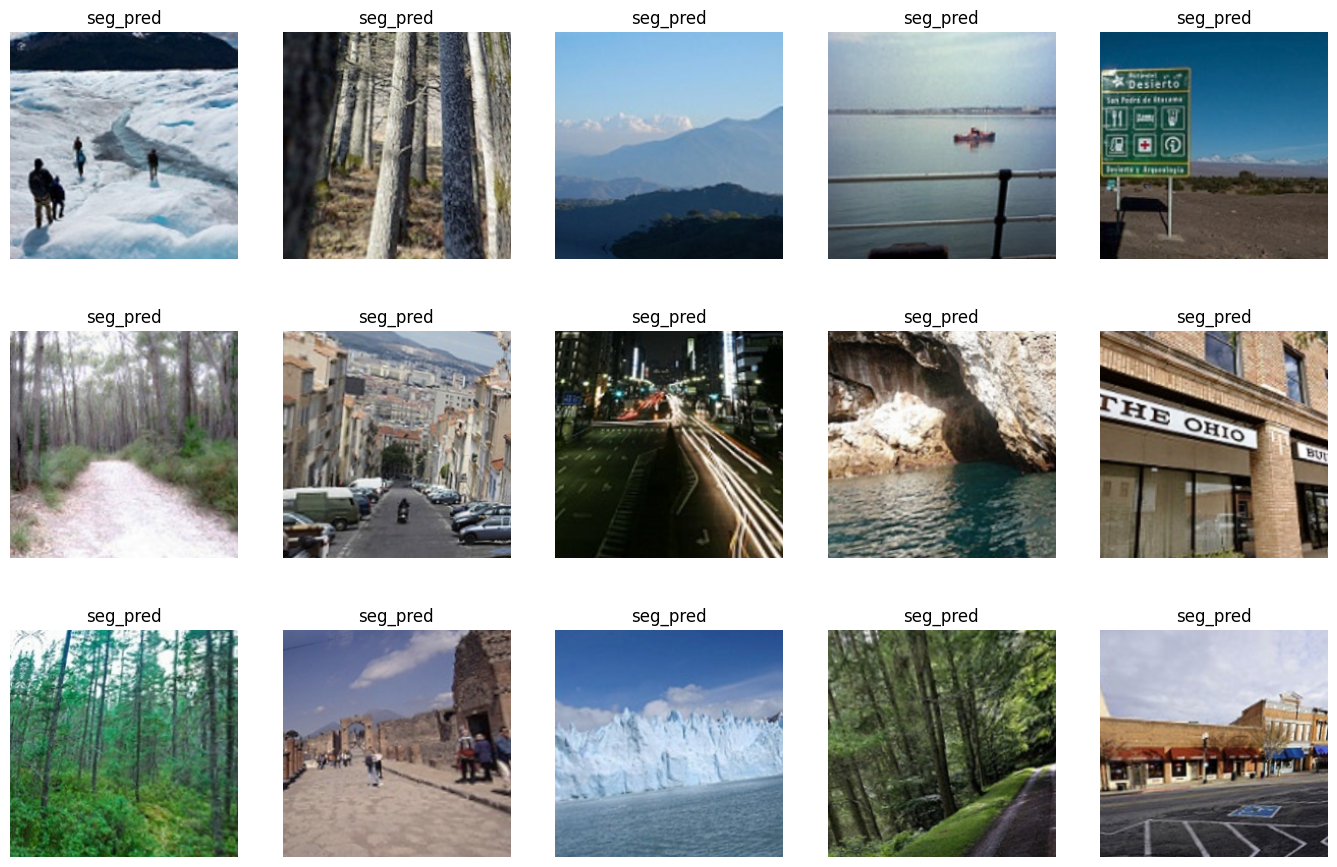

In [ ]:
# Modern fastai v2 syntax to show a 3x3 grid of images (9 total)
data.show_batch(max_n=15, nrows=3, figsize=(17, 11))


In [ ]:
# Print the list of classes found in your dataset
print(train_ds.class_names)

# Get the total number of classes
print(len(train_ds.class_names))


['seg_pred']
1


In [ ]:
from tensorflow.keras import layers, models

# 1. Get the number of classes automatically from your dataset
num_classes = len(train_ds.class_names)
print(f"Detected {num_classes} classes: {train_ds.class_names}")

# 2. Build the Model Architecture
model = models.Sequential([
    # Rescaling layer to normalize pixel values from [0, 255] to [0, 1]
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    # 1st Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 2nd Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 3rd Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten the 2D feature maps into a 1D vector
    layers.Flatten(),

    # Fully Connected (Dense) Layers for Classification
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Reduces overfitting

    # Output layer (use 'softmax' for multi-class classification)
    layers.Dense(num_classes, activation='softmax')
])

# 3. Compile the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Matches image_dataset_from_directory defaults
    metrics=['accuracy']
)

# Print a summary layout of the network
model.summary()

# 4. Train the Model
EPOCHS = 10
print(f"\n🚀 Starting training for {EPOCHS} epochs...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)


Detected 1 classes: ['seg_pred']


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting training for 10 epochs...
Epoch 1/10


/usr/local/lib/python3.13/dist-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


183/183 ━━━━━━━━━━━━━━━━━━━━ 748s 4s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 736s 4s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 725s 4s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 721s 4s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 685s 4s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 779s 4s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/10
183/183 ━━━━━━━━━━━━━━━━━━━━ 717s 4s/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e

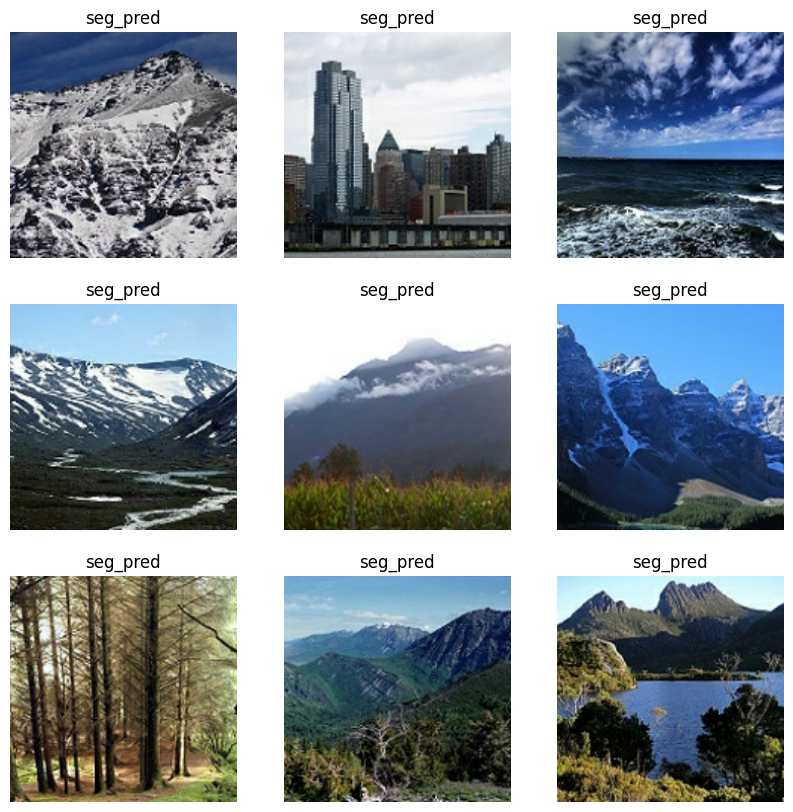

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Fetch the text labels from your dataset
class_names = train_ds.class_names

# 2. Set up a grid figure (3 rows x 3 columns)
plt.figure(figsize=(10, 10))

# 3. Take exactly one batch of images and labels from the training pipeline
for images, labels in train_ds.take(1):
    for i in range(9):  # Display the first 9 images
        ax = plt.subplot(3, 3, i + 1)

        # Cast pixels to integers for clean display plotting
        plt.imshow(images[i].numpy().astype("uint8"))

        # Add the folder name as the title of the image
        plt.title(class_names[labels[i]])
        plt.axis("off")

# 4. Render the plot grid
plt.show()


In [ ]:
data

In [ ]:
print(data.classes)
len(data.classes)
data.c

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


6

epoch,train_loss,valid_loss,accuracy,time


LR Finder is complete, type {learner_name}.recorder.plot() to see the graph.


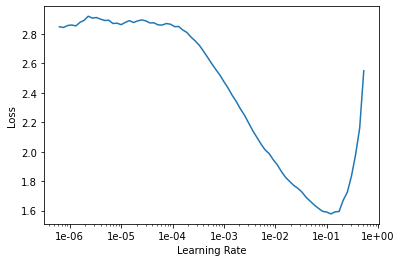

In [ ]:
learn.lr_find()
learn.recorder.plot(suggestions=True)

In [ ]:
from fastai.vision.all import *
from pathlib import Path

# 1. In fastai v2, models like resnet18 are already imported via vision.all
# No need to manually import fastai.vision.models as fastai_models

# 2. Build the learner using modern vision_learner
learn = vision_learner(
    data,
    resnet18,                       # Pass the model directly
    metrics=[accuracy],
    n_out=2,                        # <-- REPLACE 2 with your actual number of classes!
    model_dir=Path('/content/seg_pred.zip'),    # <-- Point to a directory, NOT a .zip file
    path=Path(".")
)

print("✅ Model compiled successfully using fastai ResNet18!")


✅ Model compiled successfully using fastai ResNet18!


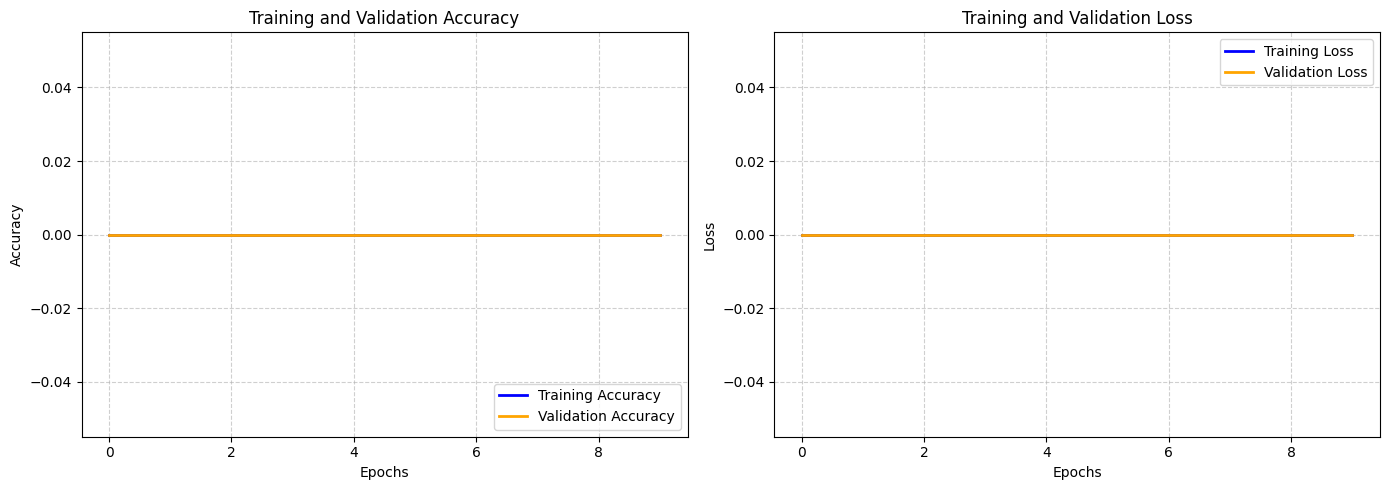

In [ ]:
# 1. Grab data from the history object created during training
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

# 2. Set up the plotting window
plt.figure(figsize=(14, 5))

# Plot 1: Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', lw=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', lw=2)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Loss Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', lw=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', lw=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Render the graphs cleanly
plt.tight_layout()
plt.show()


In [ ]:
lr1 = 1e-3
lr2 = 1e-1
learn.fit_one_cycle(40,slice(lr1,lr2))

epoch,train_loss,valid_loss,accuracy,time
0,0.405578,0.290146,0.901283,01:33
1,0.383602,0.299907,0.902708,01:29
2,0.336319,0.306456,0.911974,01:29
3,0.343718,0.326254,0.892374,01:30
4,0.364961,0.304092,0.906985,01:29
5,0.515605,0.546500,0.875624,01:30
6,0.622033,0.581009,0.892730,01:30
7,0.681928,0.578457,0.893443,01:30
8,1.094560,1.054756,0.897006,01:29
9,0.889135,1.874039,0.889522,01:30


In [ ]:
learn.unfreeze()
learn.fit_one_cycle(20,slice(1e-4,1e-3))


epoch,train_loss,valid_loss,accuracy,time
0,0.159835,0.224613,0.935495,01:29
1,0.180235,0.768976,0.919815,01:30
2,0.219724,0.273913,0.918746,01:31
3,0.214327,0.249109,0.926230,01:30
4,0.225790,1.400049,0.875267,01:31
5,0.208292,0.335781,0.908054,01:31
6,0.204567,0.318150,0.900570,01:31
7,0.182223,0.239845,0.919458,01:30
8,0.174720,0.263758,0.914469,01:31
9,0.139013,0.239959,0.928368,01:31


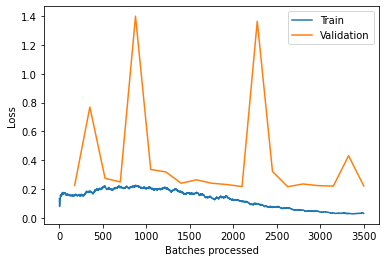

In [ ]:
learn.recorder.plot_losses()

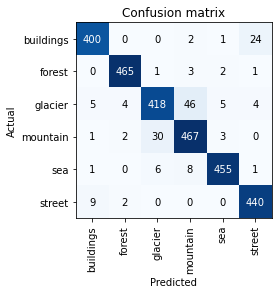

In [ ]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

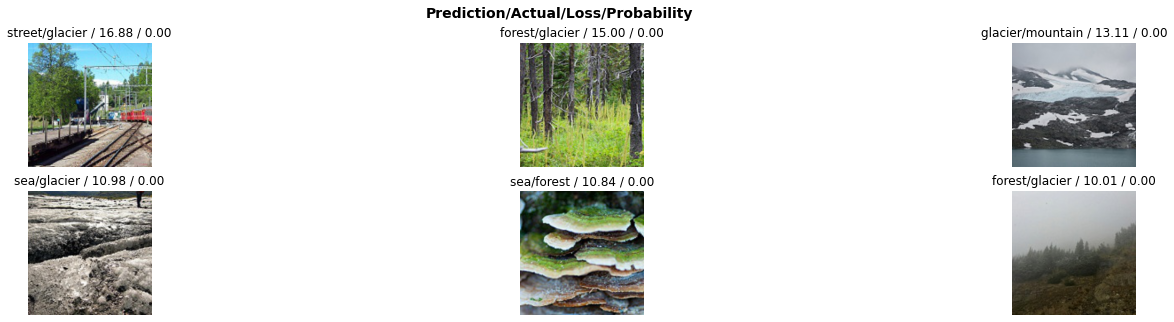

In [ ]:
interp.plot_top_losses(6,figsize = (25,5))